In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter


sns.set_context("paper", font_scale=1.3)

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

from src.data_models.caravanify import Caravanify, CaravanifyConfig

---

Total basins: 78

Distribution of basins across clusters:
predicted_cluster
0     48
10    30
Name: count, dtype: int64


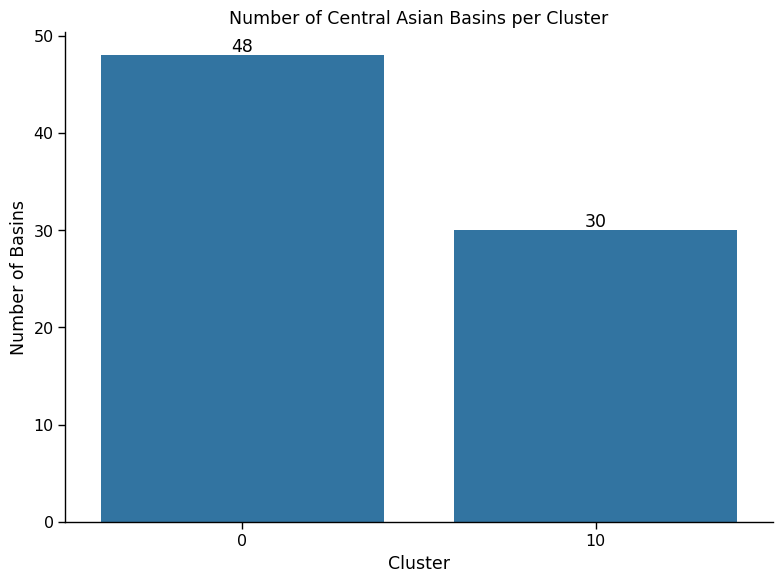

In [3]:
data = pd.read_csv(
    "/Users/cooper/Desktop/CAMELS-CH/classification_results/cluster_probabilities_11_clusters.csv"
)

# Count how many CA basins are assigned to each cluster
cluster_counts = data["predicted_cluster"].value_counts().sort_index()

# Display basic stats
print(f"Total basins: {len(data)}")
print("\nDistribution of basins across clusters:")
print(cluster_counts)

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Number of Central Asian Basins per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Basins")
plt.xticks(range(len(cluster_counts.index)), cluster_counts.index)

# Add the number of basins on top of the bars
for i, count in enumerate(cluster_counts.values):
    plt.annotate(str(count), xy=(i, count), ha="center", va="bottom")

plt.tight_layout()
sns.despine()
plt.show()

Confidence Statistics:
count    78.000000
mean      0.353828
std       0.078422
min       0.200080
25%       0.292365
50%       0.357728
75%       0.412924
max       0.505602
Name: predicted_confidence, dtype: float64


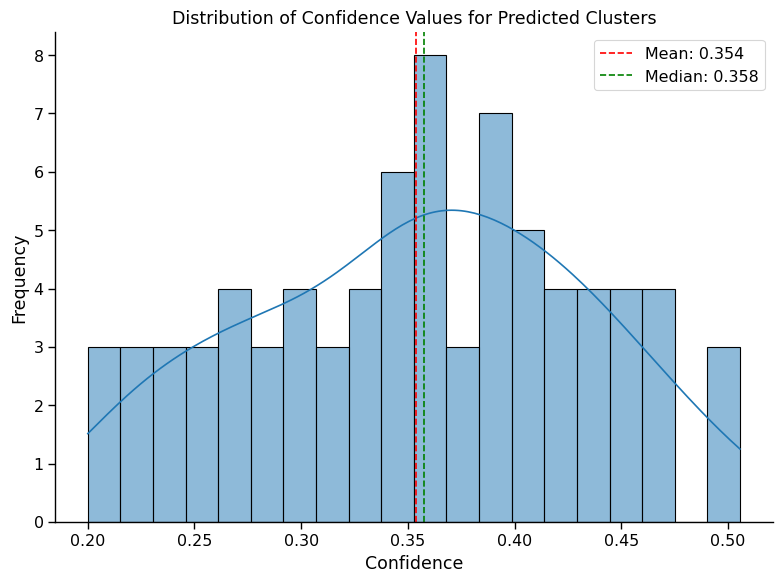

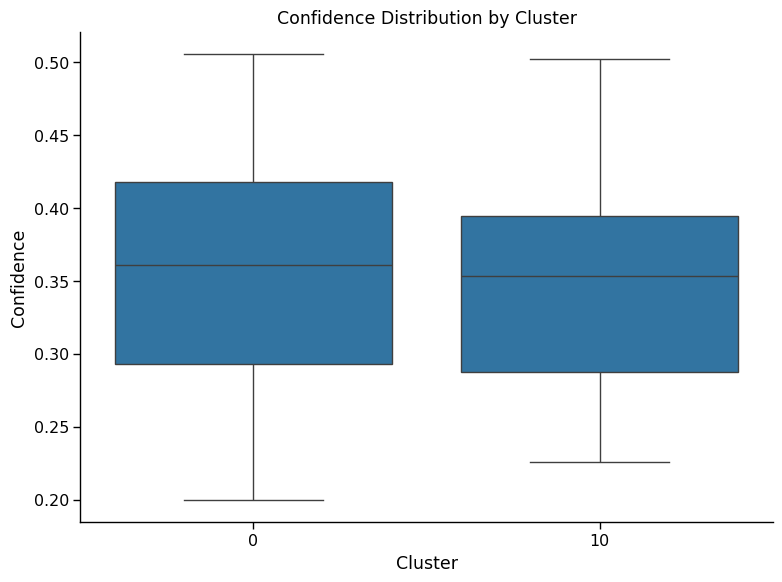

In [4]:
confidence_columns = [
    col for col in data.columns if col.startswith("cluster_") and col.endswith("_prob")
]
max_confidence = []

for index, row in data.iterrows():
    cluster = row["predicted_cluster"]
    confidence = row[f"cluster_{cluster}_prob"]
    max_confidence.append(confidence)

data["predicted_confidence"] = max_confidence

# Display summary statistics for confidence values
print("Confidence Statistics:")
print(data["predicted_confidence"].describe())

# Plot the distribution of confidence values
plt.figure(figsize=(8, 6))
sns.histplot(data["predicted_confidence"], bins=20, kde=True)
plt.title("Distribution of Confidence Values for Predicted Clusters")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.axvline(
    data["predicted_confidence"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {data['predicted_confidence'].mean():.3f}",
)
plt.axvline(
    data["predicted_confidence"].median(),
    color="green",
    linestyle="--",
    label=f"Median: {data['predicted_confidence'].median():.3f}",
)
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

# Additional analysis: Confidence by cluster
plt.figure(figsize=(8, 6))
sns.boxplot(x="predicted_cluster", y="predicted_confidence", data=data)
plt.title("Confidence Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Confidence")
plt.tight_layout()
sns.despine()
plt.show()

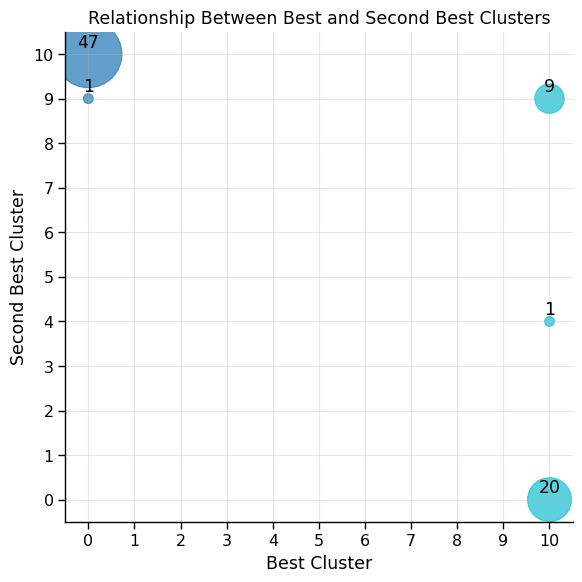

In [5]:
confidence_columns = [
    col for col in data.columns if col.startswith("cluster_") and col.endswith("_prob")
]

best_clusters = []
second_best_clusters = []

for index, row in data.iterrows():
    # Get confidence values for all clusters
    confidences = [row[col] for col in confidence_columns]
    cluster_indices = list(range(len(confidences)))

    # Sort by confidence (descending)
    sorted_indices = [cluster_indices[i] for i in np.argsort(confidences)[::-1]]

    # Store best and second best
    best_clusters.append(sorted_indices[0])
    if len(sorted_indices) > 1:
        second_best_clusters.append(sorted_indices[1])
    else:
        second_best_clusters.append(None)

# Create a dataframe with the results
cluster_df = pd.DataFrame(
    {"best_cluster": best_clusters, "second_best_cluster": second_best_clusters}
)

# Count occurrences of each best/second-best combination
combination_counts = (
    cluster_df.groupby(["best_cluster", "second_best_cluster"])
    .size()
    .reset_index(name="count")
)

# Create the scatter plot with sized markers
plt.figure(figsize=(6, 6))

# Get unique clusters for color mapping
unique_clusters = sorted(cluster_df["best_cluster"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

# Plot each best cluster with a different color
for i, cluster in enumerate(unique_clusters):
    cluster_data = combination_counts[combination_counts["best_cluster"] == cluster]
    plt.scatter(
        cluster_data["best_cluster"],
        cluster_data["second_best_cluster"],
        s=cluster_data["count"] * 50,  # Scale factor for marker size
        alpha=0.7,
        color=colors[i],
        label=f"Cluster {cluster}",
    )

    # Add count labels to the points
    for _, row in cluster_data.iterrows():
        plt.annotate(
            str(row["count"]),
            (row["best_cluster"], row["second_best_cluster"]),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
        )

plt.title("Relationship Between Best and Second Best Clusters")
plt.xlabel("Best Cluster")
plt.ylabel("Second Best Cluster")
plt.grid(True, alpha=0.3)

# Adjust axis limits to leave some space around the points
x_min, x_max = (
    cluster_df["best_cluster"].min() - 0.5,
    cluster_df["best_cluster"].max() + 0.5,
)
y_min, y_max = (
    cluster_df["second_best_cluster"].min() - 0.5,
    cluster_df["second_best_cluster"].max() + 0.5,
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Set integer ticks for both axes
plt.xticks(range(int(x_min), int(x_max) + 1))
plt.yticks(range(int(y_min), int(y_max) + 1))

plt.tight_layout()
sns.despine()
plt.show()

In [6]:
basin_groups = []

for index, row in data.iterrows():
    gauge_id = row["gauge_id"]

    # Get confidence values for all clusters
    confidences = [row[col] for col in confidence_columns]
    cluster_indices = list(range(len(confidences)))

    # Sort by confidence (descending)
    sorted_indices = [cluster_indices[i] for i in np.argsort(confidences)[::-1]]

    # Get top two choices as a frozenset (order doesn't matter)
    top_two = frozenset(sorted_indices[:2])

    basin_groups.append(
        {
            "gauge_id": gauge_id,
            "top_two_clusters": top_two,
            "first_choice": sorted_indices[0],
            "second_choice": sorted_indices[1],
            "first_confidence": confidences[sorted_indices[0]],
            "second_confidence": confidences[sorted_indices[1]],
        }
    )

# Convert to DataFrame
basin_groups_df = pd.DataFrame(basin_groups)

# Group by the top two clusters and count
group_counts = (
    basin_groups_df.groupby("top_two_clusters").size().reset_index(name="count")
)
group_counts["top_two_list"] = group_counts["top_two_clusters"].apply(
    lambda x: sorted(list(x))
)

# Sort by count for better readability
group_counts = group_counts.sort_values("count", ascending=False)

# Display the groups and counts
print(
    f"Found {len(group_counts)} distinct basin groups based on top two cluster choices"
)
print("\nTop basin groups:")
for idx, row in group_counts.iterrows():
    print(f"Group {idx + 1}: Clusters {row['top_two_list']} - {row['count']} basins")

# Create a detailed view of each group
print("\nDetailed view of basin groups:")
for idx, group in enumerate(group_counts["top_two_clusters"]):
    basins_in_group = basin_groups_df[basin_groups_df["top_two_clusters"] == group]
    count = len(basins_in_group)
    clusters = sorted(list(group))

    # Count how many have each cluster as first choice
    first_choices = Counter(basins_in_group["first_choice"])

    print(f"\nGroup {idx + 1}: Clusters {clusters} - {count} basins")
    print(
        f"  Basins with cluster {clusters[0]} as first choice: {first_choices.get(clusters[0], 0)}"
    )
    print(
        f"  Basins with cluster {clusters[1]} as first choice: {first_choices.get(clusters[1], 0)}"
    )
    print("  Basin IDs in this group:")

    # Display gauge_ids in compact format
    basin_list = basins_in_group["gauge_id"].tolist()
    for i in range(0, len(basin_list), 5):  # Show 5 per line
        print(f"    {', '.join(basin_list[i : i + 5])}")

Found 4 distinct basin groups based on top two cluster choices

Top basin groups:
Group 2: Clusters [0, 10] - 67 basins
Group 1: Clusters [9, 10] - 9 basins
Group 3: Clusters [0, 9] - 1 basins
Group 4: Clusters [4, 10] - 1 basins

Detailed view of basin groups:

Group 1: Clusters [0, 10] - 67 basins
  Basins with cluster 0 as first choice: 47
  Basins with cluster 10 as first choice: 20
  Basin IDs in this group:
    CA_15016, CA_15020, CA_15022, CA_15025, CA_15030
    CA_15034, CA_15039, CA_15040, CA_15044, CA_15045
    CA_15049, CA_15069, CA_15070, CA_15081, CA_15083
    CA_15090, CA_15102, CA_15149, CA_15171, CA_15189
    CA_15194, CA_15212, CA_15214, CA_15215, CA_15216
    CA_15256, CA_15278, CA_15283, CA_15285, CA_15287
    CA_15312, CA_16055, CA_16059, CA_16068, CA_16070
    CA_16096, CA_16100, CA_16101, CA_16121, CA_16127
    CA_16136, CA_16146, CA_16151, CA_16153, CA_16158
    CA_16159, CA_16160, CA_16161, CA_16169, CA_16176
    CA_16205, CA_16487, CA_16510, CA_17050, CA_17082


In [8]:
# Define group1 clusters
group1_clusters = frozenset([0, 10])


def assign_to_major_group(row):
    # Get the top choices from the row
    first_choice = row["first_choice"]
    second_choice = row["second_choice"]

    # Create a set of the top choices for easier comparison
    top_choices = frozenset([first_choice, second_choice])

    # If first or second choice is in group1, assign to Group 1
    if first_choice in [0, 10] or second_choice in [0, 10]:
        return "Group 1 [0, 10]"
    else:
        # If neither is in group1, assign to some other group
        # You need to define this assignment logic
        return "Other Group"  # You'll need to replace this with your actual logic


# Apply the assignment function
basin_groups_df["major_group"] = basin_groups_df.apply(assign_to_major_group, axis=1)

# Count basins in each major group
major_group_counts = basin_groups_df["major_group"].value_counts()

# Display the reassignment results
print("Basins reassigned to major groups:")
print(major_group_counts)

# Show details of each major group
print("\nDetailed view after reassignment:")
for group_name in major_group_counts.index:
    group_basins = basin_groups_df[basin_groups_df["major_group"] == group_name]
    print(f"\n{group_name} - {len(group_basins)} basins")

    # Count original top_two_clusters within this major group
    if "top_two_clusters" in group_basins.columns:
        original_groups = group_basins["top_two_clusters"].value_counts()
        print("Original groups within this major group:")
        for orig_group, count in original_groups.items():
            print(f"  {sorted(list(orig_group))} - {count} basins")

    # Show which basins were reassigned
    if group_name == "Group 1 [0, 10]":
        # Define what constitutes a reassigned basin - those that weren't already in group1_clusters
        reassigned = group_basins[
            ~group_basins["top_two_clusters"].apply(
                lambda x: x == group1_clusters or 0 in x or 10 in x
            )
        ]

        if len(reassigned) > 0:
            print(f"\nReassigned basins to {group_name}:")
            for _, row in reassigned.iterrows():
                print(
                    f"  {row['gauge_id']} - Original top choices: {sorted(list(row['top_two_clusters']))}, First choice: {row['first_choice']}"
                )

# Create a table of gauge IDs by major group
major_groups_table = {}
for group_name in major_group_counts.index:
    major_groups_table[group_name] = basin_groups_df[
        basin_groups_df["major_group"] == group_name
    ]["gauge_id"].tolist()

# Save the reassigned groups to a CSV
basin_groups_df[["gauge_id", "major_group", "first_choice", "second_choice"]].to_csv(
    "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_11_clusters.csv",
    index=False,
)
print(
    "\nReassigned groups saved to '/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_11_clusters.csv'"
)

Basins reassigned to major groups:
major_group
Group 1 [0, 10]    78
Name: count, dtype: int64

Detailed view after reassignment:

Group 1 [0, 10] - 78 basins
Original groups within this major group:
  [0, 10] - 67 basins
  [9, 10] - 9 basins
  [0, 9] - 1 basins
  [4, 10] - 1 basins

Reassigned groups saved to '/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_11_clusters.csv'


---